In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current folder:
c:\Users\arjun\OneDrive\Desktop\ABTalks\Day15

Files in current folder:
['day15.ipynb', 'Telco-Customer-Churn.txt']


In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   



In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [7]:
print("Unique values in Churn:")
print(df["Churn"].unique())

print("\nChurn counts:")
print(df["Churn"].value_counts())

Unique values in Churn:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.unique())

Features shape: (7043, 20)
Target shape: (7043,)

Target values:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [10]:
y = y.map({"No": 0, "Yes": 1})

print("Converted target values:")
print(y.unique())

print("\nTarget counts:")
print(y.value_counts())

Converted target values:
[0 1]

Target counts:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:")
print(X.shape)

print("\nAll features are numeric:")
print(X.dtypes.value_counts())

Features after encoding:
(7043, 13601)

All features are numeric:
bool       13598
int64          2
float64        1
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 13601)
Testing data: (1409, 13601)


In [13]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")


Logistic Regression model trained successfully!


In [14]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.7963094393186657
Model Accuracy (%): 79.63094393186657


Confusion Matrix:
[[920 115]
 [172 202]]


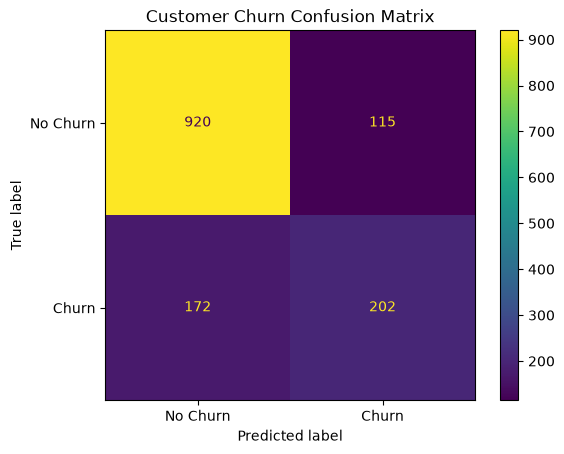

In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Customer Churn Confusion Matrix")
plt.show()

In [17]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [18]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 920
False Positives: 115
False Negatives: 172
True Positives  : 202


In [19]:
prediction_results = pd.DataFrame({
    "Actual Churn": y_test.values,
    "Predicted Churn": y_pred
})

prediction_results.to_csv(
    "prediction_results.csv",
    index=False
)

print("Prediction results saved successfully!")
print("\nFirst 10 predictions:")
print(prediction_results.head(10))

Prediction results saved successfully!

First 10 predictions:
   Actual Churn  Predicted Churn
0             0                0
1             0                1
2             0                0
3             0                0
4             0                0
5             0                1
6             0                0
7             0                0
8             0                0
9             1                0


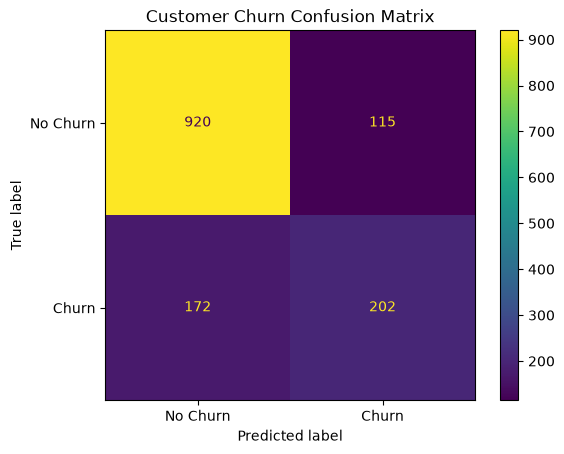

Confusion matrix saved successfully!


In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Customer Churn Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved successfully!")